# Projeto Acadêmico de IA — Grupo 13
### Otimização de Entregas com Foco no Entregador

**Disciplina:** MDC050 — Inteligência Artificial | **Turma:** ENGCDM2B
**Trio:** Vitor Carvalho de Santana, Henri de Macedo Bezerra (líder), Pedro Augusto Machado Cardoso

Agente que encontra a melhor rota de entrega para um motoboy na região de Aldeota, Fortaleza

## 1. Configuração inicial e obtenção do grafo real

In [12]:
!pip install --upgrade osmnx --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 4.6 MB/s eta 0:00:00


In [13]:
import math
import time
import heapq
import random
import itertools
from collections import deque
from dataclasses import dataclass, field

import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
G = ox.graph_from_place(
    "Aldeota, Fortaleza, Brazil",
    network_type="drive",
    custom_filter='["highway"~"primary|secondary|tertiary"]'
)
print("Grafo original:", G.number_of_nodes(), "nós,", G.number_of_edges(), "arestas")


Grafo original: 102 nós, 166 arestas


Gera um grafo da região de Aldeota, Fortaleza, região de atuação do nosso projeto. Contudo, esse grafo resultante (G) possui suas coordenadas em graus, pois leva em consideração a latitude e longitude.

In [24]:
G_proj = ox.project_graph(G)
G_consolidado = ox.consolidate_intersections(
    G_proj, tolerance=10, rebuild_graph=True, dead_ends=True
)
print("Grafo consolidado:", G_consolidado.number_of_nodes(), "nós,", G_consolidado.number_of_edges(), "arestas")

Grafo consolidado: 73 nós, 134 arestas


`G_proj = ox.project_graph(G)` resolve o problema mencionado acima, pois converte o grafo com localizações em graus para uma projeção cartográfica local em metros, escolhendo automaticamente a zona UTM correta para a região de Fortaleza.

**Algo que decidimos foi unir nós que estivessem a menos de 10 metros de distância um do outro a fins de facilitar a visualização.**

In [ ]:
no_exemplo = list(G.nodes)[0]
print(G.nodes[no_exemplo])

{'y': -3.733645, 'x': -38.5063139, 'highway': 'traffic_signals', 'ref': '54', 'street_count': 4}


In [ ]:
aresta_exemplo = list(G.edges)[0]
print(G.edges[aresta_exemplo])

{'osmid': 436565576, 'highway': 'primary', 'lanes': '2', 'maxspeed': '50', 'name': 'Avenida Santos Dumont', 'oneway': True, 'reversed': False, 'length': np.float64(7.40874670684647)}


Este grafo exibe a rede de ruas da região de Aldeota, Fortaleza, conforme obtido do OpenStreetMap. Cada ponto (nó) representa uma interseção ou um ponto de interesse na rede, e cada linha (aresta) representa uma rua ou trecho de via. A visualização ajuda a entender a topologia da rede de transporte.

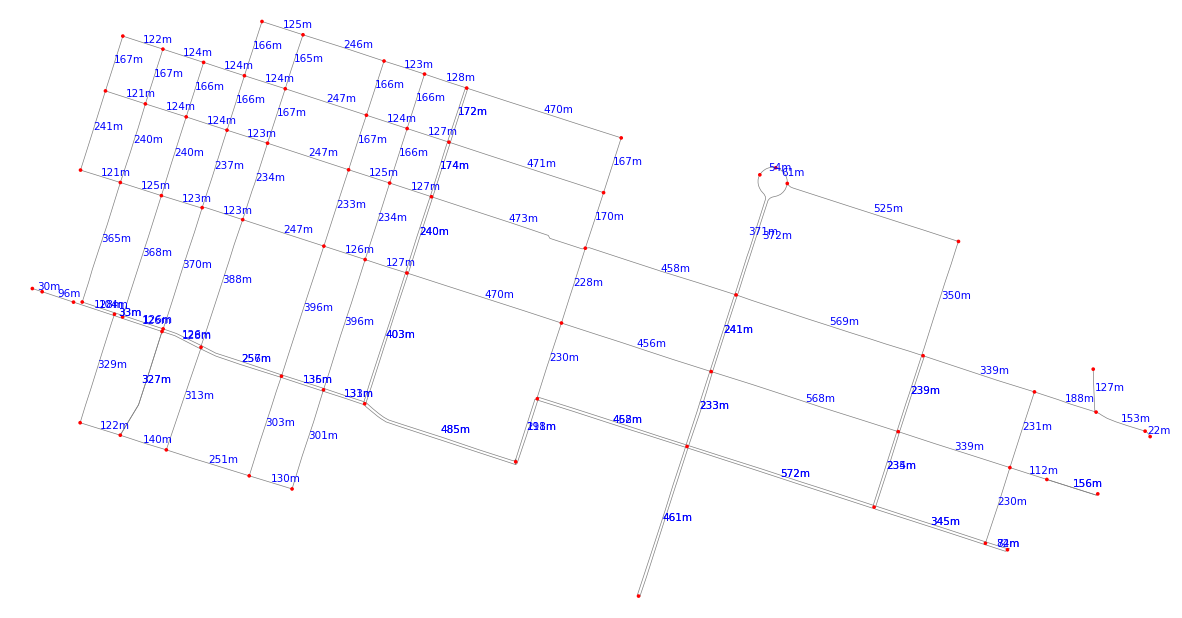

In [31]:
fig, ax = ox.plot_graph(
    G_consolidado, figsize=(15, 15),
    node_size=7,
    edge_linewidth=0.5,
    show=False, close=False,
    bgcolor="white", edge_color="grey", node_color="red"
    )

for u, v, dados in G_consolidado.edges(data=True):
    x_medio = (G_consolidado.nodes[u]['x'] + G_consolidado.nodes[v]['x']) / 2
    y_medio = (G_consolidado.nodes[u]['y'] + G_consolidado.nodes[v]['y']) / 2

    distancia = dados['length']
    if isinstance(distancia, list):
        distancia = sum(distancia)  # soma os trechos fundidos em um só valor

    ax.text(x_medio, y_medio, f"{distancia:.0f}m", fontsize=7.5, color="blue")

plt.show()

Esse trecho é responsável pela plotagem do grafo e também por adicionar uma visualização dos tamanhos das arestas, ou melhor, das distâncias entre os nós.


In [ ]:
G_consolidado.nodes[list(G_consolidado.nodes)[0]]

{'osmid_original': [253406715, 253406716],
 'x': 554823.2751167953,
 'y': 9587297.631875942,
 'cluster': 0,
 'ref': '54',
 'highway': 'traffic_signals',
 'street_count': 4}

## 2. Formulação em espaço de estados

- **Estado:** um nó do grafo (cruzamento/interseção real em Aldeota), identificado pelo ID do OpenStreetMap. É a posição atual do motoboy.
- **Estado inicial:** o nó do **restaurante** de onde o motoboy sai (um dos 5 restaurantes fixos da Seção 3).
- **Ações:** `ACOES(s)` = mover-se para um cruzamento vizinho, ou seja, para qualquer sucessor de `s` no grafo **direcionado** (respeita o sentido das vias de mão única).
- **Função de transição:** `RESULTADO(s, a) = a` — ao escolher ir para o cruzamento vizinho `a`, o motoboy passa a estar em `a`.
- **Teste de objetivo:** `s == nó do cliente` (o ponto de entrega sorteado).
- **Custo de caminho:** soma do campo `length` (metros) de cada aresta percorrida. Quando há arestas paralelas entre dois cruzamentos, usa-se a de menor comprimento.

A classe abaixo traduz essa formulação diretamente em código. Os algoritmos de busca das Seções 4 e 5 só enxergam o problema por meio desses métodos.

In [ ]:
def custo_aresta(G, u, v):
    return min(d.get("length", float("inf")) for d in G[u][v].values())


class ProblemaEntrega:

    def __init__(self, G, estado_inicial, estado_objetivo):
        self.G = G
        self.inicial = estado_inicial
        self.objetivo = estado_objetivo

    def acoes(self, estado):
        return list(self.G.successors(estado))

    def resultado(self, estado, acao):
        return acao

    def teste_objetivo(self, estado):
        return estado == self.objetivo

    def custo_passo(self, estado, acao):
        return custo_aresta(self.G, estado, self.resultado(estado, acao))

    def custo_caminho(self, caminho):
        return sum(custo_aresta(self.G, u, v) for u, v in zip(caminho[:-1], caminho[1:]))


@dataclass
class ResultadoBusca:
    algoritmo: str
    caminho: list
    custo: float
    nos_expandidos: int
    tempo_ms: float
    expandidos: list = field(default_factory=list, repr=False)

def reconstruir_caminho(pais, objetivo):
    caminho = [objetivo]
    while pais[caminho[-1]] is not None:
        caminho.append(pais[caminho[-1]])
    return caminho[::-1]

## 3. Definir a origem e destino do problema

**Origem — restaurantes fixos.** Cinco cruzamentos reais da malha de Aldeota foram fixados como restaurantes (os mesmos dos testes do grupo). Como são IDs do OpenStreetMap, eles continuam válidos em qualquer mapa baixado que contenha a região.

**Destino — cliente aleatório.** A cada entrega, um cliente é sorteado entre os cruzamentos que são **alcançáveis** a partir do restaurante (a rede é direcionada e filtrada, então nem todo nó é alcançável de todo outro). Assim o sorteio sempre gera um problema com solução, sem precisar de tentativas e erros. O sorteio também evita repetir o mesmo restaurante e o mesmo cliente da rodada anterior.

**Restaurante bem conectado.** Um restaurante só é útil se o motoboy conseguir sair dele. Por isso cada restaurante precisa estar na **maior componente fortemente conexa** do grafo (região onde qualquer cruzamento alcança qualquer outro). Se um nó fixado estiver num trecho sem saída, ele é movido para o cruzamento conectado mais próximo.

In [ ]:
restaurantes = {
    "RESTAURANTE_1": 2781404056,
    "RESTAURANTE_2": 587735144,
    "RESTAURANTE_3": 11850855197,
    "RESTAURANTE_4": 8730897396,
    "RESTAURANTE_5": 476794326,
}

def maior_componente_forte(G):
    return max(nx.strongly_connected_components(G), key=len)

def no_mais_proximo(G, lat, lon, candidatos=None):
    candidatos = list(G.nodes) if candidatos is None else list(candidatos)
    return min(candidatos, key=lambda n: ox.distance.great_circle(lat, lon, G.nodes[n]["y"], G.nodes[n]["x"]))

componente_G = maior_componente_forte(G)
lat_ref = float(np.mean([d["y"] for _, d in G.nodes(data=True)]))
lon_ref = float(np.mean([d["x"] for _, d in G.nodes(data=True)]))

for nome, no in list(restaurantes.items()):
    if no in componente_G:
        continue
    lat, lon = (G.nodes[no]["y"], G.nodes[no]["x"]) if no in G else (lat_ref, lon_ref)
    usados = set(restaurantes.values())
    novo = no_mais_proximo(G, lat, lon, componente_G - usados)
    motivo = "não existe no grafo atual" if no not in G else "não tem saída para o resto da malha"
    print(f"Aviso: {nome} ({no}) {motivo}; realocado para o cruzamento {novo}.")
    restaurantes[nome] = novo

coords_restaurantes = {nome: (G.nodes[no]["y"], G.nodes[no]["x"]) for nome, no in restaurantes.items()}

print("Pontos de restaurante definidos:")
for nome, no in restaurantes.items():
    lat, lon = coords_restaurantes[nome]
    print(f"  {nome} = nó {no}  (lat {lat:.5f}, lon {lon:.5f})")

Aviso: RESTAURANTE_1 (2781404056) não tem saída para o resto da malha; realocado para o cruzamento 4544824716.
Aviso: RESTAURANTE_3 (11850855197) não tem saída para o resto da malha; realocado para o cruzamento 587735148.
Aviso: RESTAURANTE_4 (8730897396) não tem saída para o resto da malha; realocado para o cruzamento 265021160.
Pontos de restaurante definidos:
  RESTAURANTE_1 = nó 4544824716  (lat -3.74285, lon -38.49122)
  RESTAURANTE_2 = nó 587735144  (lat -3.74172, lon -38.49477)
  RESTAURANTE_3 = nó 587735148  (lat -3.74021, lon -38.49966)
  RESTAURANTE_4 = nó 265021160  (lat -3.73642, lon -38.51538)
  RESTAURANTE_5 = nó 476794326  (lat -3.73224, lon -38.50579)


In [ ]:

ultimo_restaurante = None
ultimo_cliente = None


def sortear_entrega(G, restaurantes, nome_restaurante=None):
    global ultimo_restaurante, ultimo_cliente

    if nome_restaurante is None:
        opcoes = [n for n, no in restaurantes.items() if no != ultimo_restaurante] or list(restaurantes)
        nome_restaurante = random.choice(opcoes)
    origem = restaurantes[nome_restaurante]

    ids_restaurantes = set(restaurantes.values())
    alcancaveis = nx.descendants(G, origem)
    candidatos = [n for n in alcancaveis if n not in ids_restaurantes and n != ultimo_cliente]
    if not candidatos:
        raise ValueError(f"Nenhum cliente alcançável a partir de {nome_restaurante}.")

    cliente = random.choice(candidatos)
    ultimo_restaurante, ultimo_cliente = origem, cliente
    return nome_restaurante, origem, cliente

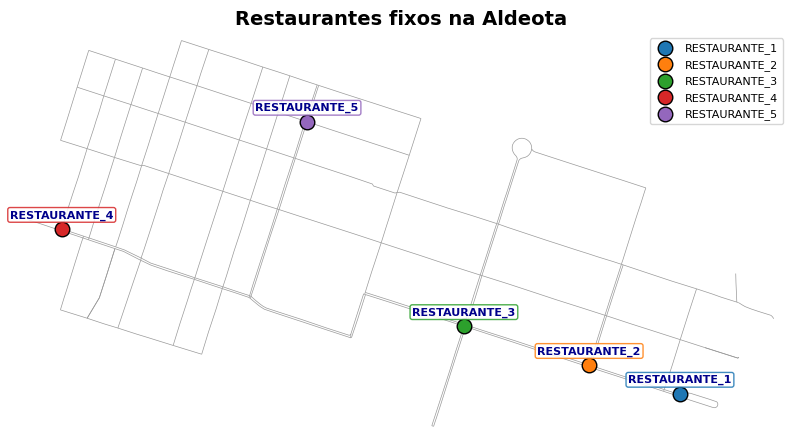

In [ ]:
def desenhar_restaurantes(ax, G, restaurantes, origem_ativa=None):
    cores = plt.get_cmap("tab10")
    for i, (nome, no) in enumerate(restaurantes.items()):
        x, y = G.nodes[no]["x"], G.nodes[no]["y"]
        ativo = no == origem_ativa
        ax.scatter(x, y, s=230 if ativo else 110, color=cores(i),
                   edgecolors="red" if ativo else "black", linewidth=2.5 if ativo else 1,
                   zorder=6, label=f"{nome}{' (origem)' if ativo else ''}")
        ax.annotate(nome, (x, y), textcoords="offset points", xytext=(0, 8), ha="center",
                    fontsize=8, fontweight="bold", color="darkblue", zorder=7,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=cores(i), alpha=0.85))


def desenhar_cliente(ax, G, cliente):
    x, y = G.nodes[cliente]["x"], G.nodes[cliente]["y"]
    ax.scatter(x, y, s=200, color="red", marker="X", edgecolors="black", zorder=8,
               label=f"Cliente ({cliente})")
    ax.annotate("Cliente", (x, y), textcoords="offset points", xytext=(0, 10), ha="center",
                fontsize=9, fontweight="bold", color="darkred", zorder=9,
                bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.9))


def legenda_sem_repeticao(ax, loc="upper right"):
    handles, labels = ax.get_legend_handles_labels()
    unicos = dict(zip(labels, handles))
    ax.legend(unicos.values(), unicos.keys(), loc=loc, fontsize=8)


fig, ax = ox.plot_graph(G, show=False, close=False, bgcolor="white",
                        edge_linewidth=0.5, node_size=0, figsize=(10, 10))
desenhar_restaurantes(ax, G, restaurantes)
ax.set_title("Restaurantes fixos na Aldeota", fontsize=14, fontweight="bold")
legenda_sem_repeticao(ax)
plt.show()

## 4. Busca não-informada

**Algoritmo escolhido: Busca de Custo Uniforme (UCS / Dijkstra).** Ela expande sempre o estado com menor custo de caminho acumulado `g(n)`. Como todos os custos de passo são positivos (comprimentos de vias), a UCS é **completa e ótima**: a primeira vez que o objetivo sai da fronteira, a rota encontrada é a mais curta.

O teste de objetivo é feito **ao retirar** o estado da fronteira (e não ao gerá-lo) — é isso que garante a otimalidade.

**Complemento — Busca em Largura (BFS).** Também implementamos a BFS para o experimento. Ela minimiza o **número de cruzamentos** e não a distância, então serve para mostrar que uma busca não informada que ignora os custos pode devolver uma rota mais longa.

In [ ]:
def busca_custo_uniforme(problema):
    t0 = time.perf_counter()
    desempate = itertools.count()                   # evita comparar IDs quando g empata
    fronteira = [(0.0, next(desempate), problema.inicial)]
    g = {problema.inicial: 0.0}                     # melhor custo conhecido até cada estado
    pais = {problema.inicial: None}
    fechados = set()
    ordem_expansao = []

    while fronteira:
        custo, _, estado = heapq.heappop(fronteira)
        if estado in fechados:                      # entrada obsoleta na fila
            continue
        ordem_expansao.append(estado)

        if problema.teste_objetivo(estado):
            caminho = reconstruir_caminho(pais, estado)
            return ResultadoBusca("Custo Uniforme", caminho, custo, len(ordem_expansao),
                                  (time.perf_counter() - t0) * 1000, ordem_expansao)

        fechados.add(estado)
        for acao in problema.acoes(estado):
            filho = problema.resultado(estado, acao)
            novo_g = custo + problema.custo_passo(estado, acao)
            if filho not in fechados and novo_g < g.get(filho, float("inf")):
                g[filho] = novo_g
                pais[filho] = estado
                heapq.heappush(fronteira, (novo_g, next(desempate), filho))

    return ResultadoBusca("Custo Uniforme", None, float("inf"), len(ordem_expansao),
                          (time.perf_counter() - t0) * 1000, ordem_expansao)


def busca_em_largura(problema):
    t0 = time.perf_counter()
    if problema.teste_objetivo(problema.inicial):
        return ResultadoBusca("Largura (BFS)", [problema.inicial], 0.0, 0, 0.0, [])

    fronteira = deque([problema.inicial])
    pais = {problema.inicial: None}
    ordem_expansao = []

    while fronteira:
        estado = fronteira.popleft()
        ordem_expansao.append(estado)
        for acao in problema.acoes(estado):
            filho = problema.resultado(estado, acao)
            if filho not in pais:
                pais[filho] = estado
                if problema.teste_objetivo(filho):
                    caminho = reconstruir_caminho(pais, filho)
                    return ResultadoBusca("Largura (BFS)", caminho, problema.custo_caminho(caminho),
                                          len(ordem_expansao), (time.perf_counter() - t0) * 1000,
                                          ordem_expansao)
                fronteira.append(filho)

    return ResultadoBusca("Largura (BFS)", None, float("inf"), len(ordem_expansao),
                          (time.perf_counter() - t0) * 1000, ordem_expansao)

## 5. Heurística e Busca A*
**Heurística:** distância em linha reta (distância geodésica pela fórmula de *haversine*) entre o cruzamento atual e o cruzamento do cliente, calculada a partir de latitude e longitude:

$$h(n) = 2R \cdot \arcsin\sqrt{\sin^2\!\left(\tfrac{\Delta\varphi}{2}\right) + \cos\varphi_n \cos\varphi_d \sin^2\!\left(\tfrac{\Delta\lambda}{2}\right)}, \quad R = 6\,371\,009 \text{ m}$$

**Justificativa de admissibilidade:** a distância em linha reta nunca é maior que a distância real percorrida pelas vias, que sempre seguem um caminho igual ou mais longo que a reta — portanto a heurística nunca superestima o custo real, ou seja, $h(n) \le h^*(n)$. Isso vale de forma rigorosa aqui porque o OSMnx calcula o `length` de cada aresta somando distâncias geodésicas (com o mesmo raio $R$) ao longo da geometria da via, e nenhuma curva entre dois pontos da esfera é mais curta que a geodésica entre eles. Também vale $h(\text{objetivo}) = 0$.

**Consistência (monotonicidade):** para qualquer aresta $n \to n'$, pela desigualdade triangular, $h(n) \le c(n, n') + h(n')$. Por ser consistente, o A* pode usar um conjunto de estados fechados (nunca reabre um nó) sem perder a otimalidade.

A* expande o estado com menor $f(n) = g(n) + h(n)$. A heurística "puxa" a busca na direção do cliente, então ela tende a expandir **bem menos nós** que a UCS e encontra a **mesma distância ótima**.

In [ ]:
R_TERRA = 6_371_009


def haversine(lat1, lon1, lat2, lon2):
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi = p2 - p1
    dlmb = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dlmb / 2) ** 2
    return 2 * R_TERRA * math.asin(math.sqrt(min(1.0, a)))


def heuristica_linha_reta(G, destino):

    lat_d, lon_d = G.nodes[destino]["y"], G.nodes[destino]["x"]

    def h(n):
        return haversine(G.nodes[n]["y"], G.nodes[n]["x"], lat_d, lon_d)

    return h


def busca_a_estrela(problema, fabrica_heuristica=heuristica_linha_reta):
    t0 = time.perf_counter()
    h = fabrica_heuristica(problema.G, problema.objetivo)
    desempate = itertools.count()
    fronteira = [(h(problema.inicial), next(desempate), 0.0, problema.inicial)]  # (f, desempate, g, estado)
    g = {problema.inicial: 0.0}
    pais = {problema.inicial: None}
    fechados = set()
    ordem_expansao = []

    while fronteira:
        _, _, custo, estado = heapq.heappop(fronteira)
        if estado in fechados:
            continue
        ordem_expansao.append(estado)

        if problema.teste_objetivo(estado):
            caminho = reconstruir_caminho(pais, estado)
            return ResultadoBusca("A*", caminho, custo, len(ordem_expansao),
                                  (time.perf_counter() - t0) * 1000, ordem_expansao)

        fechados.add(estado)
        for acao in problema.acoes(estado):
            filho = problema.resultado(estado, acao)
            novo_g = custo + problema.custo_passo(estado, acao)
            if filho not in fechados and novo_g < g.get(filho, float("inf")):
                g[filho] = novo_g
                pais[filho] = estado
                heapq.heappush(fronteira, (novo_g + h(filho), next(desempate), novo_g, filho))

    return ResultadoBusca("A*", None, float("inf"), len(ordem_expansao),
                          (time.perf_counter() - t0) * 1000, ordem_expansao)

### 5.1 Verificação empírica da admissibilidade e da corretude

Além da justificativa teórica, conferimos no mapa real:
1. **Admissibilidade:** calculamos o custo real $h^*(n)$ de **todos** os nós até um destino (Dijkstra no grafo invertido) e verificamos que $h(n) \le h^*(n)$ em todos eles.
2. **Corretude:** comparamos as distâncias encontradas pela nossa UCS e pelo nosso A* com a função pronta `nx.shortest_path_length` do NetworkX.

In [ ]:
random.seed(13)
_, origem_teste, destino_teste = sortear_entrega(G, restaurantes)

# 1) h(n) <= h*(n) para todos os nós que alcançam o destino
custo_real = nx.single_source_dijkstra_path_length(G.reverse(copy=False), destino_teste, weight="length")
h = heuristica_linha_reta(G, destino_teste)
violacoes = [n for n, d in custo_real.items() if h(n) > d + 1e-6]
razoes = [h(n) / d for n, d in custo_real.items() if d > 0]
print(f"Nós verificados: {len(custo_real)}")
print(f"Violações de admissibilidade (h > h*): {len(violacoes)}")
print(f"Maior razão h/h*: {max(razoes):.4f}  (≤ 1 → admissível)")
print(f"Razão média h/h*: {np.mean(razoes):.4f}  (quanto mais perto de 1, mais informativa)")

# 2) Nossas buscas vs. NetworkX
prob = ProblemaEntrega(G, origem_teste, destino_teste)
ref = nx.shortest_path_length(G, origem_teste, destino_teste, weight="length")
ucs, ast = busca_custo_uniforme(prob), busca_a_estrela(prob)
print(f"\nNetworkX: {ref:.2f} m | UCS: {ucs.custo:.2f} m | A*: {ast.custo:.2f} m")
assert math.isclose(ucs.custo, ref, rel_tol=1e-9) and math.isclose(ast.custo, ref, rel_tol=1e-9)
print("✔ UCS e A* encontraram a distância ótima.")

Nós verificados: 93
Violações de admissibilidade (h > h*): 0
Maior razão h/h*: 1.0000  (≤ 1 → admissível)
Razão média h/h*: 0.8465  (quanto mais perto de 1, mais informativa)

NetworkX: 1559.23 m | UCS: 1559.23 m | A*: 1559.23 m
✔ UCS e A* encontraram a distância ótima.


## 6. Simulação de entrega: restaurante fixo → cliente aleatório

Cada execução da célula abaixo sorteia um restaurante e um cliente novos, roda o **A\*** para encontrar a rota mais curta e mostra no mapa a rota, os restaurantes, o cliente e a distância de cada trecho de via. A UCS é executada no mesmo problema para confirmar a distância e comparar o esforço de busca.

> Para fixar o restaurante, passe o nome: `sortear_entrega(G, restaurantes, "RESTAURANTE_2")`.

Restaurante sorteado : RESTAURANTE_3 (nó 587735148)
Cliente sorteado     : nó 482156294
Distância da rota    : 1563.43 m (1.56 km)
Cruzamentos na rota  : 10

Algoritmo         Nós expandidos   Distância (m)  Tempo (ms)
Custo Uniforme                43         1563.43       0.283
A*                            23         1563.43       0.299


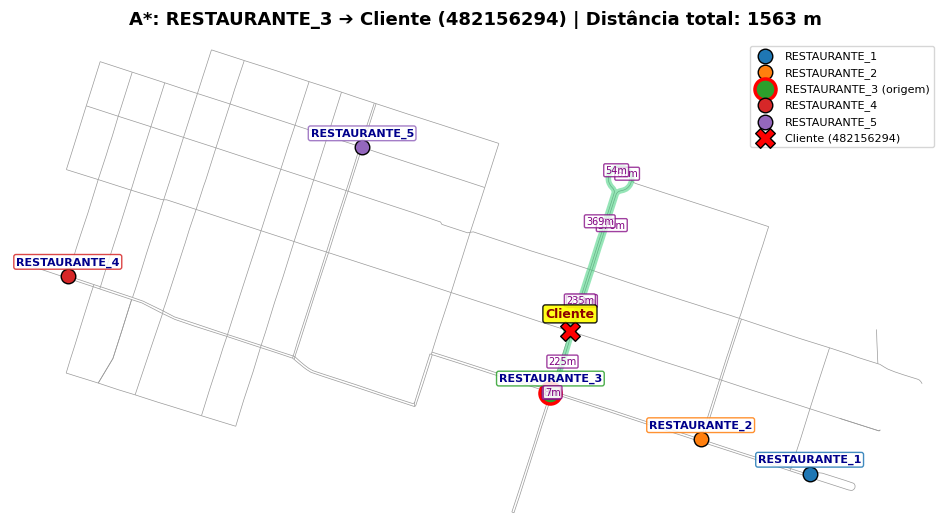

In [ ]:
def plotar_rota_entrega(G, restaurantes, nome_restaurante, origem, cliente, resultado):
    rota = resultado.caminho
    fig, ax = ox.plot_graph_route(G, rota, route_color="#2ecc71", route_linewidth=4, node_size=0,
                                  edge_linewidth=0.5, bgcolor="white", figsize=(12, 12),
                                  show=False, close=False)
    desenhar_restaurantes(ax, G, restaurantes, origem_ativa=origem)
    desenhar_cliente(ax, G, cliente)

    # Distância de cada trecho da rota
    for u, v in zip(rota[:-1], rota[1:]):
        mid_x = (G.nodes[u]["x"] + G.nodes[v]["x"]) / 2
        mid_y = (G.nodes[u]["y"] + G.nodes[v]["y"]) / 2
        ax.annotate(f"{custo_aresta(G, u, v):.0f}m", (mid_x, mid_y), color="purple", fontsize=7,
                    ha="center", va="center", zorder=7,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="purple", alpha=0.75))

    ax.set_title(f"{resultado.algoritmo}: {nome_restaurante} ➔ Cliente ({cliente}) | "
                 f"Distância total: {resultado.custo:.0f} m",
                 fontsize=13, fontweight="bold", pad=12)
    legenda_sem_repeticao(ax)
    plt.show()


# ---------- Nova entrega ----------
nome_rest, origem, cliente = sortear_entrega(G, restaurantes)
problema = ProblemaEntrega(G, origem, cliente)

res_astar = busca_a_estrela(problema)
res_ucs = busca_custo_uniforme(problema)

print(f"Restaurante sorteado : {nome_rest} (nó {origem})")
print(f"Cliente sorteado     : nó {cliente}")
print(f"Distância da rota    : {res_astar.custo:.2f} m ({res_astar.custo / 1000:.2f} km)")
print(f"Cruzamentos na rota  : {len(res_astar.caminho)}")
print(f"\n{'Algoritmo':<16}{'Nós expandidos':>16}{'Distância (m)':>16}{'Tempo (ms)':>12}")
for r in (res_ucs, res_astar):
    print(f"{r.algoritmo:<16}{r.nos_expandidos:>16}{r.custo:>16.2f}{r.tempo_ms:>12.3f}")

plotar_rota_entrega(G, restaurantes, nome_rest, origem, cliente, res_astar)

### 6.1 Onde cada algoritmo procurou

Os pontos coloridos são os cruzamentos **expandidos** por cada busca na mesma entrega. A UCS se espalha em todas as direções (como uma onda a partir do restaurante), enquanto o A* concentra a busca na direção do cliente — e ainda assim as duas chegam à mesma distância.

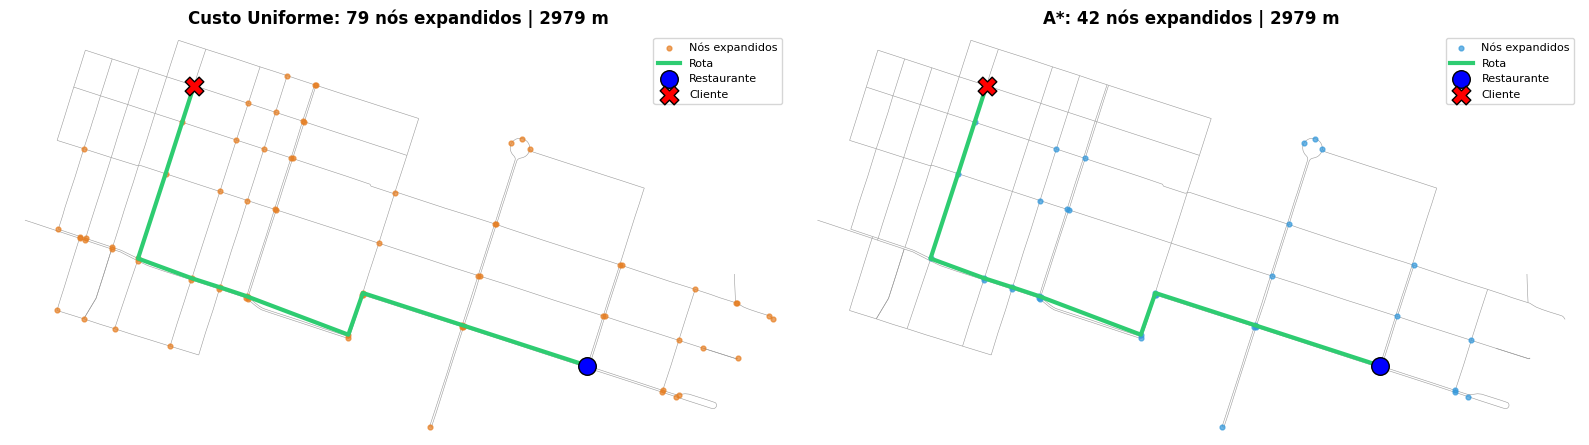

In [ ]:
fig, eixos = plt.subplots(1, 2, figsize=(16, 8))
for ax, r, cor in zip(eixos, (res_ucs, res_astar), ("#e67e22", "#3498db")):
    ox.plot_graph(G, ax=ax, node_size=0, edge_linewidth=0.4, edge_color="#999999",
                  bgcolor="white", show=False, close=False)
    xs = [G.nodes[n]["x"] for n in r.expandidos]
    ys = [G.nodes[n]["y"] for n in r.expandidos]
    ax.scatter(xs, ys, s=12, color=cor, alpha=0.7, zorder=4, label="Nós expandidos")
    rx = [G.nodes[n]["x"] for n in r.caminho]
    ry = [G.nodes[n]["y"] for n in r.caminho]
    ax.plot(rx, ry, color="#2ecc71", linewidth=3, zorder=5, label="Rota")
    ax.scatter(*[G.nodes[origem][k] for k in ("x", "y")], s=160, color="blue", edgecolors="black", zorder=6, label="Restaurante")
    ax.scatter(*[G.nodes[cliente][k] for k in ("x", "y")], s=180, color="red", marker="X", edgecolors="black", zorder=6, label="Cliente")
    ax.set_title(f"{r.algoritmo}: {r.nos_expandidos} nós expandidos | {r.custo:.0f} m", fontweight="bold")
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 7. Três mapas de tamanhos diferentes

Para o experimento usamos três malhas viárias reais, centradas em Aldeota, com tamanhos crescentes:

| Mapa | Descrição |
|---|---|
| **Pequeno** | Aldeota, apenas vias principais (`primary`, `secondary`, `tertiary`) — o grafo `G` usado até aqui |
| **Médio** | Aldeota, todas as vias trafegáveis por veículos (`network_type="drive"`) |
| **Grande** | Raio de 3 km a partir do centro de Aldeota, todas as vias (inclui Meireles, Varjota, Centro etc.) |

Nos mapas médio e grande, cada restaurante é localizado pelo **cruzamento mais próximo** de suas coordenadas (a mesma posição geográfica do mapa pequeno).

In [ ]:
centro_aldeota = (float(np.mean([d["y"] for _, d in G.nodes(data=True)])),
                  float(np.mean([d["x"] for _, d in G.nodes(data=True)])))

G_medio = ox.graph_from_place("Aldeota, Fortaleza, Brazil", network_type="drive")
G_grande = ox.graph_from_point(centro_aldeota, dist=3000, network_type="drive")

MAPAS = {
    "Pequeno": G,
    "Médio": G_medio,
    "Grande": G_grande,
}

tabela_mapas = pd.DataFrame(
    [{"Mapa": nome, "Nós (cruzamentos)": Gm.number_of_nodes(), "Arestas (vias)": Gm.number_of_edges()}
     for nome, Gm in MAPAS.items()]
).set_index("Mapa")
tabela_mapas

,Nós (cruzamentos),Arestas (vias)
Mapa,,
Pequeno,102,166
Médio,489,917
Grande,3331,6916


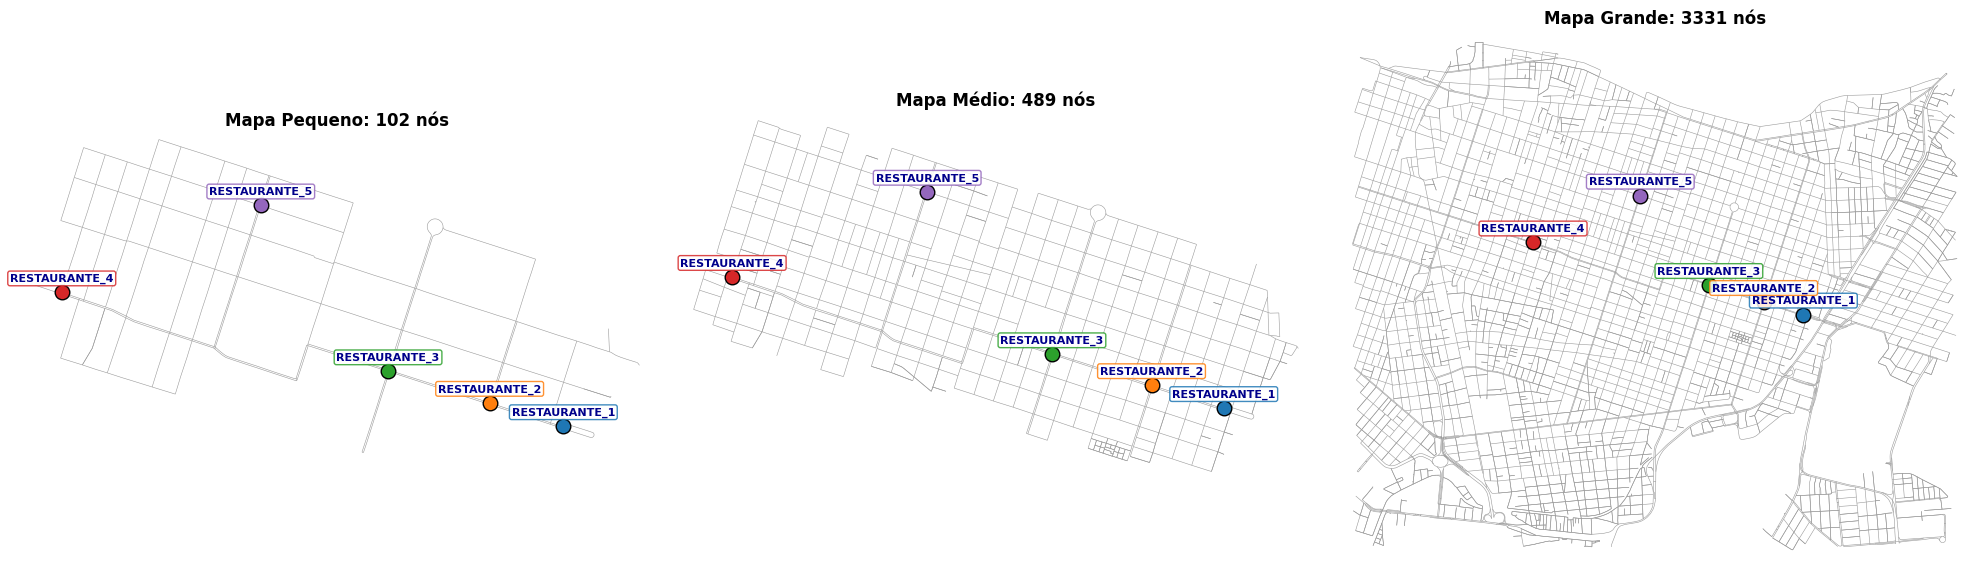

In [ ]:

restaurantes_por_mapa = {}
for nome_mapa, Gm in MAPAS.items():
    comp = maior_componente_forte(Gm)
    restaurantes_por_mapa[nome_mapa] = {
        r: (restaurantes[r] if restaurantes[r] in comp else no_mais_proximo(Gm, *coords_restaurantes[r], comp))
        for r in restaurantes
    }

fig, eixos = plt.subplots(1, 3, figsize=(20, 7))
for ax, (nome_mapa, Gm) in zip(eixos, MAPAS.items()):
    ox.plot_graph(Gm, ax=ax, node_size=0, edge_linewidth=0.4, bgcolor="white", show=False, close=False)
    desenhar_restaurantes(ax, Gm, restaurantes_por_mapa[nome_mapa])
    ax.set_title(f"Mapa {nome_mapa}: {Gm.number_of_nodes()} nós", fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Experimento comparativo (tabela e gráfico)

**Protocolo:** em cada mapa, para cada um dos 5 restaurantes, sorteamos 4 clientes aleatórios alcançáveis (semente fixa = 13, para o experimento ser reprodutível) — **20 entregas por mapa**. Cada entrega é resolvida pelos três algoritmos, e registramos:
- **nós expandidos** (esforço de busca);
- **custo da rota** (distância em metros);
- **tempo de execução** (ms).

In [ ]:
ALGORITMOS = {
    "Largura (BFS)": busca_em_largura,
    "Custo Uniforme": busca_custo_uniforme,
    "A*": busca_a_estrela,
}
CLIENTES_POR_RESTAURANTE = 4
random.seed(13)

registros = []
for nome_mapa, Gm in MAPAS.items():
    rest_mapa = restaurantes_por_mapa[nome_mapa]
    ids_rest = set(rest_mapa.values())
    for nome_rest, origem_m in rest_mapa.items():
        alcancaveis = sorted(nx.descendants(Gm, origem_m) - ids_rest)
        for cliente_m in random.sample(alcancaveis, min(CLIENTES_POR_RESTAURANTE, len(alcancaveis))):
            prob = ProblemaEntrega(Gm, origem_m, cliente_m)
            for nome_alg, algoritmo in ALGORITMOS.items():
                r = algoritmo(prob)
                registros.append({
                    "Mapa": nome_mapa,
                    "Nós no mapa": Gm.number_of_nodes(),
                    "Restaurante": nome_rest,
                    "Cliente": cliente_m,
                    "Algoritmo": nome_alg,
                    "Nós expandidos": r.nos_expandidos,
                    "Custo (m)": r.custo,
                    "Tempo (ms)": r.tempo_ms,
                })

df = pd.DataFrame(registros)
df["Mapa"] = pd.Categorical(df["Mapa"], categories=list(MAPAS), ordered=True)
df["Algoritmo"] = pd.Categorical(df["Algoritmo"], categories=list(ALGORITMOS), ordered=True)
print(f"{len(df)} execuções registradas ({len(df) // len(ALGORITMOS)} entregas).")
df.head(9)

180 execuções registradas (60 entregas).


,Mapa,Nós no mapa,Restaurante,Cliente,Algoritmo,Nós expandidos,Custo (m),Tempo (ms)
0,Pequeno,102,RESTAURANTE_1,477358144,Largura (BFS),70,3179.469298,0.290708
1,Pequeno,102,RESTAURANTE_1,477358144,Custo Uniforme,71,3179.469298,8.872487
2,Pequeno,102,RESTAURANTE_1,477358144,A*,32,3179.469298,1.026221
3,Pequeno,102,RESTAURANTE_1,477466813,Largura (BFS),84,3919.959614,4.335640
4,Pequeno,102,RESTAURANTE_1,477466813,Custo Uniforme,85,3587.351144,7.003637
5,Pequeno,102,RESTAURANTE_1,477466813,A*,59,3587.351144,6.030911
6,Pequeno,102,RESTAURANTE_1,476794330,Largura (BFS),49,2905.363529,0.170800
7,Pequeno,102,RESTAURANTE_1,476794330,Custo Uniforme,59,2905.363529,0.626595
8,Pequeno,102,RESTAURANTE_1,476794330,A*,37,2905.363529,0.515088


In [ ]:

por_entrega = df.pivot_table(index=["Mapa", "Restaurante", "Cliente"], columns="Algoritmo",
                             values="Custo (m)", observed=True)
mesmo_custo = np.isclose(por_entrega["Custo Uniforme"], por_entrega["A*"]).all()
print("UCS e A* encontraram a mesma distância em todas as entregas:", mesmo_custo)

excesso_bfs = (por_entrega["Largura (BFS)"] / por_entrega["Custo Uniforme"] - 1) * 100
print(f"BFS devolveu rota mais longa em {(excesso_bfs > 1e-6).sum()} de {len(excesso_bfs)} entregas "
      f"(em média {excesso_bfs.mean():.1f}% mais longa).")

UCS e A* encontraram a mesma distância em todas as entregas: True
BFS devolveu rota mais longa em 36 de 60 entregas (em média 4.7% mais longa).


### 8.1 Tabela de resultados (média das 20 entregas por mapa)

In [ ]:
tabela = (df.groupby(["Mapa", "Algoritmo"], observed=True)
            .agg(**{"Nós no mapa": ("Nós no mapa", "first"),
                    "Nós expandidos (média)": ("Nós expandidos", "mean"),
                    "Custo da rota (m, média)": ("Custo (m)", "mean"),
                    "Tempo (ms, média)": ("Tempo (ms)", "mean")})
            .round(2))
tabela

Nós no mapa  Nós expandidos (média)  \
Mapa    Algoritmo                                             
Pequeno Largura (BFS)           102                   49.75   
        Custo Uniforme          102                   55.05   
        A*                      102                   25.40   
Médio   Largura (BFS)           489                  267.00   
        Custo Uniforme          489                  277.05   
        A*                      489                   89.40   
Grande  Largura (BFS)          3331                 1404.10   
        Custo Uniforme         3331                 1386.85   
        A*                     3331                  271.15   

                        Custo da rota (m, média)  Tempo (ms, média)  
Mapa    Algoritmo                                                    
Pequeno Largura (BFS)                    2118.93               0.61  
        Custo Uniforme                   2093.49               2.39  
        A*                               2093.49               0.78  
Médio   Largura (BFS)                    1840.77               2.01  
        Custo Uniforme                   1802.49              10.45  
        A*                               1802.49               6.00  
Grande  Largura (BFS)                    3031.52              10.01  
        Custo Uniforme                   2711.33              63.02  
        A*                               2711.33              16.27

In [ ]:

medias = df.groupby(["Mapa", "Algoritmo"], observed=True)[["Nós expandidos", "Tempo (ms)"]].mean()
ganho = pd.DataFrame({
    "Redução de nós expandidos (%)": (1 - medias.xs("A*", level="Algoritmo")["Nós expandidos"]
                                      / medias.xs("Custo Uniforme", level="Algoritmo")["Nós expandidos"]) * 100,
    "Redução de tempo (%)": (1 - medias.xs("A*", level="Algoritmo")["Tempo (ms)"]
                             / medias.xs("Custo Uniforme", level="Algoritmo")["Tempo (ms)"]) * 100,
}).round(1)
ganho

,Redução de nós expandidos (%),Redução de tempo (%)
Mapa,,
Pequeno,53.9,67.4
Médio,67.7,42.6
Grande,80.4,74.2


## 8.2 Conclusão

- **Rota ótima:** a Busca de Custo Uniforme e o A* encontraram exatamente a mesma distância em todas as entregas, o que confirma na prática que ambas são ótimas para o custo em metros — no caso do A*, graças à heurística de linha reta ser **admissível** (e consistente), verificado também empiricamente na Seção 5.1.
- **Eficiência:** o A* expande bem menos cruzamentos que a UCS, porque a heurística orienta a busca na direção do cliente, enquanto a UCS se espalha em todas as direções. Em valor absoluto, a economia de nós cresce com o tamanho do mapa (ver tabela de ganho e gráfico de escalabilidade), o que torna o A* a escolha natural para o agente em cidades inteiras.
- **Busca em largura:** minimiza o número de cruzamentos, não a distância; por isso pode devolver rotas mais longas. Ela costuma ser a mais rápida em milissegundos (não usa fila de prioridade nem soma custos), mas isso não compensa a rota errada: serve como contraponto para mostrar a importância de considerar o custo do caminho.
- **Limitação da Fase 1:** o agente encontra a rota **mais curta em distância**, mas não sabe nada sobre lombadas, semáforos ou horário de pico — e a rota mais curta raramente é a mais rápida para o entregador.